In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [63]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [64]:
print ("shape :" , df.shape)

shape : (1470, 35)


In [65]:
print (df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [66]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Analyse Discriptive**

In [67]:
Attrition = df["Attrition"].value_counts()
Attrition


,count
Attrition,
No,1233
Yes,237


In [68]:
Age_avg = df.groupby ("Attrition")["Age"].mean ()
Age_avg

,Age
Attrition,
No,37.561233
Yes,33.607595


In [69]:
Anciennete_avg = df.groupby ("Attrition")["YearsAtCompany"].mean()
Anciennete_avg

,YearsAtCompany
Attrition,
No,7.369019
Yes,5.130802


In [70]:
Masse_Salaire =df.groupby ("Attrition") ["MonthlyIncome"].mean()
Masse_Salaire

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


In [71]:
DailyRate_avg = df.groupby ("Attrition") ["DailyRate"].mean()
DailyRate_avg

,DailyRate
Attrition,
No,812.504461
Yes,750.362869


In [72]:
Department = df.groupby ("Attrition")["Department"].value_counts()
Department

Attrition  Department            
No         Research & Development    828
           Sales                     354
           Human Resources            51
Yes        Research & Development    133
           Sales                      92
           Human Resources            12
Name: count, dtype: int64

In [73]:
Distance_Home = df.groupby ("Attrition")["DistanceFromHome"].mean()
Distance_Home

,DistanceFromHome
Attrition,
No,8.915653
Yes,10.632911


In [74]:
Gender = df.groupby ("Attrition")["Gender"].value_counts()
Gender

Attrition  Gender
No         Male      732
           Female    501
Yes        Male      150
           Female     87
Name: count, dtype: int64

**Exploitation de Donnée**

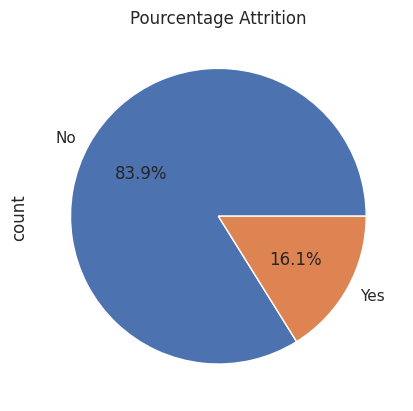

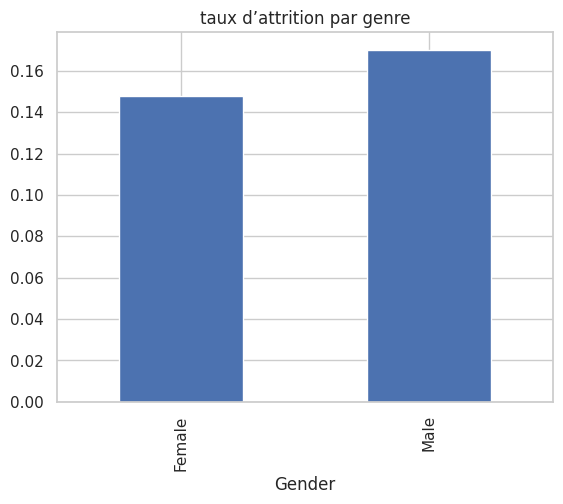

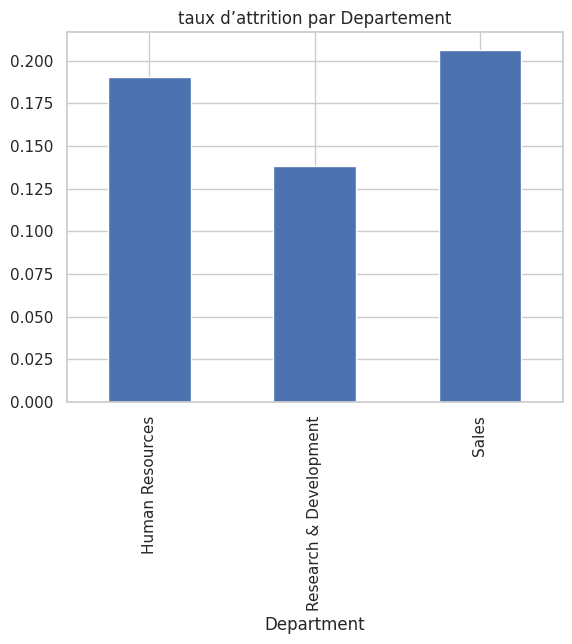

In [75]:

Attrition.plot(kind='pie', autopct='%1.1f%%')
plt.title('Pourcentage Attrition')
plt.show()

df.groupby('Gender')['Attrition'].apply(lambda x: (x=='Yes').mean()).plot(kind='bar')
plt.title('taux d’attrition par genre')
plt.show()

df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()).plot(kind='bar')
plt.title('taux d’attrition par Departement')
plt.show()


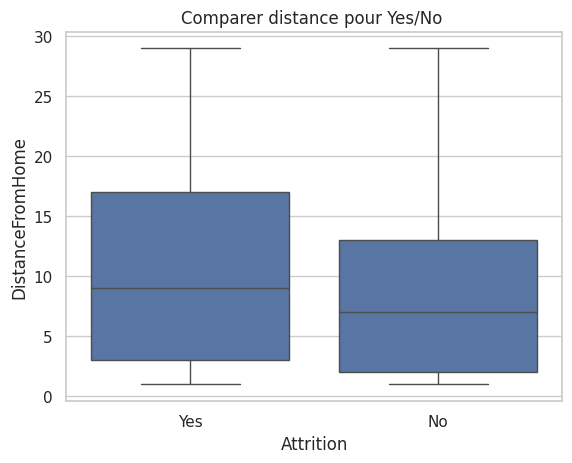

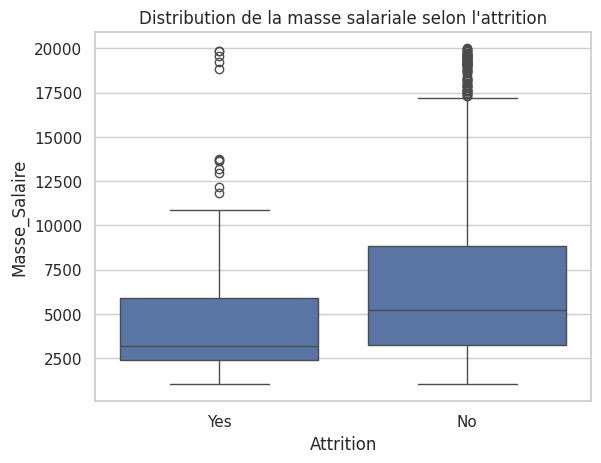

In [76]:
import seaborn as sns
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df)
plt.title('Comparer distance pour Yes/No ')
plt.show()


sns.set(style="whitegrid")

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Distribution de la masse salariale selon l'attrition")
plt.ylabel("Masse_Salaire")
plt.xlabel("Attrition")
plt.show()

# **Model Superviser**

In [77]:
target = "Attrition"

In [78]:
X= df.drop(columns=target)


In [79]:
y= df[target]

**Séparation de donnée**

In [80]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
num_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [81]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
cat_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

**Transformation de Colonnes **

In [82]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [83]:
categorical_pipe = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot",OneHotEncoder(handle_unknown= "ignore"))
])

In [84]:
preproces = ColumnTransformer(transformers=[
    ("num" , numeric_pipe , num_cols),
    ("cat" , categorical_pipe , cat_cols )

])

# RandomForsetClassifier

In [85]:
model = RandomForestClassifier(
       n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",  # <-- le point clé !
    random_state=42
)


In [86]:
clf = Pipeline(steps=[
    ("preprocess", preproces),
    ("model", model)
])

**Diviser Test et Train**

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [88]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education', 'EmployeeCount',
                                                   'EmployeeNumber',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompa...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'Over18', 'OverTime'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

In [89]:
y_pred = clf.predict(X_test)

In [90]:
y_proba = clf.predict_proba(X_test)[:, 1]

In [91]:
print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

          No      0.883     0.919     0.901       247
         Yes      0.459     0.362     0.405        47

    accuracy                          0.830       294
   macro avg      0.671     0.640     0.653       294
weighted avg      0.816     0.830     0.821       294



In [92]:
auc = roc_auc_score(y_test, y_proba)

In [93]:
print("ROC AUC:", round(auc, 3))

ROC AUC: 0.79


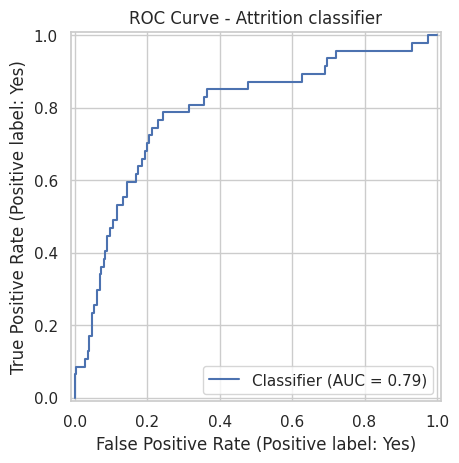

In [94]:
RocCurveDisplay.from_predictions(y_test, y_proba, pos_label='Yes')
plt.title("ROC Curve - Attrition classifier")
plt.show()

## Récuperer les colonnes categorials




In [95]:
ohe = clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

In [96]:
cat_feature_names = ohe.get_feature_names_out(cat_cols)

In [97]:
feature_names = np.r_[num_cols, cat_feature_names]

In [98]:
importances = clf.named_steps["model"].feature_importances_

In [99]:
top = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

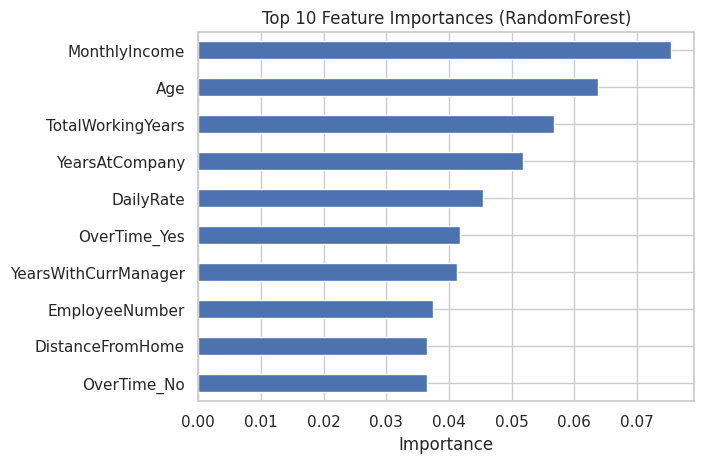

In [100]:
plt.figure()
top.sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances (RandomForest)")
plt.xlabel("Importance")
plt.show()

# **Model Non Superviser**





In [101]:
X.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Model KMeans

In [102]:
# Transformer les colonnes catégorielles de X en variables numériques
current_cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
X = pd.get_dummies(X, columns=current_cat_cols, drop_first=True)

In [103]:
features = [
    "Age", "DailyRate","DistanceFromHome" , "Education", "EmployeeCount" ,"EnvironmentSatisfaction" , "MonthlyIncome", "TotalWorkingYears", "OverTime_Yes"

]

In [104]:
Xc = X[features].copy()

In [105]:
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc)


In [106]:
inertias = []

In [107]:
K_range = range(2, 11)

In [108]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init="auto")
    kmeans.fit(Xc_scaled)
    inertias.append(kmeans.inertia_)

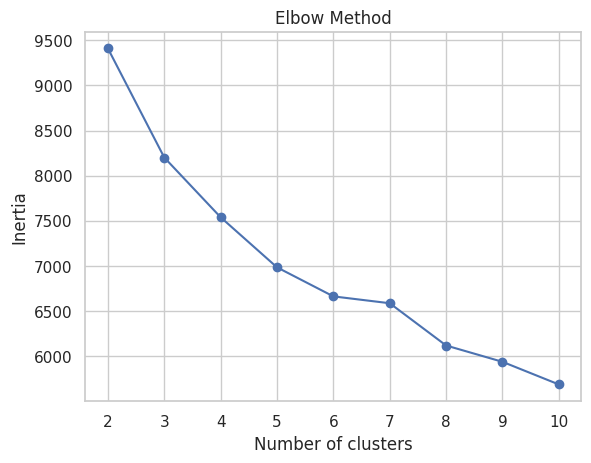

In [109]:
plt.figure()
plt.plot(list(K_range),inertias,marker = "o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [110]:
k=3
kmeans = KMeans(n_clusters=k, random_state=42)

In [111]:
clusters = kmeans.fit_predict(Xc_scaled)

In [112]:
X["cluster"] = clusters


In [113]:
cluster_summary = (
    X.groupby("cluster")[features]
    .mean()
    .round(2)
    .sort_values(by="MonthlyIncome", ascending=False)
)

print(cluster_summary)

           Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
cluster                                                                 
2        48.20     811.78              8.83       3.07            1.0   
1        35.12     815.41              9.38       2.85            1.0   
0        34.36     794.53              9.22       2.89            1.0   

         EnvironmentSatisfaction  MonthlyIncome  TotalWorkingYears  \
cluster                                                              
2                           2.72       14798.89              24.59   
1                           2.83        4924.03               8.76   
0                           2.68        4719.23               8.41   

         OverTime_Yes  
cluster                
2                0.26  
1                1.00  
0                0.00  


In [114]:
pca=PCA(n_components=2, random_state=42)

In [115]:
X_pca = pca.fit_transform(Xc_scaled)

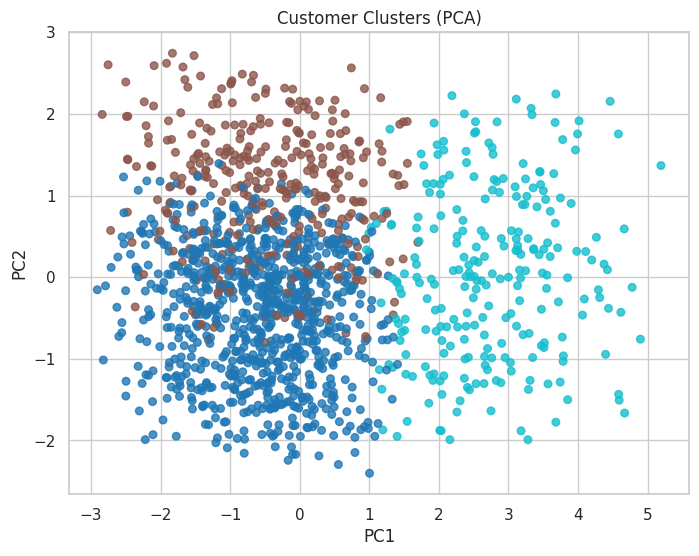

In [116]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    s=30,
    alpha=0.8
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Clusters (PCA)")
plt.show()



In [117]:
from sklearn.metrics import silhouette_score

score = silhouette_score(Xc_scaled, clusters)
print("silhouette_score", round(score,3))

silhouette_score 0.196


In [118]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [119]:
labels = kmeans.labels_
df['cluster'] = labels
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'cluster'],
      dtype='object')


***Variables catégorielles (countplot / proportion)***

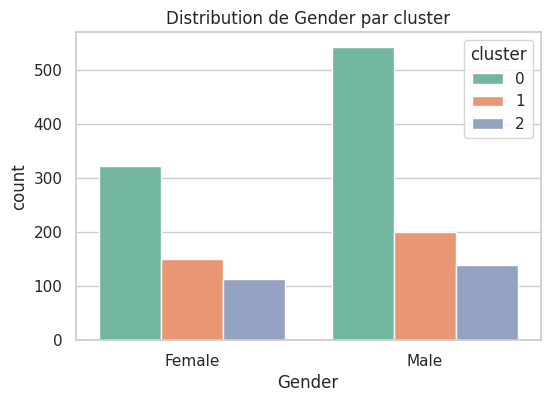

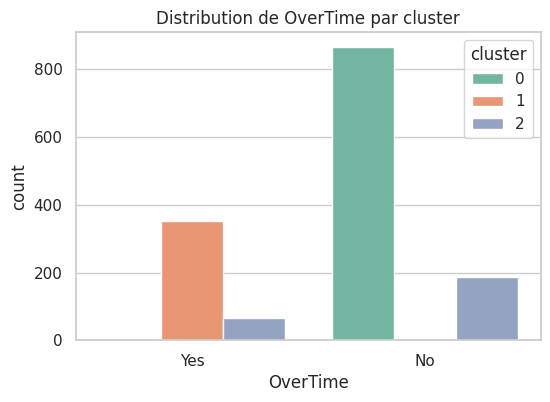

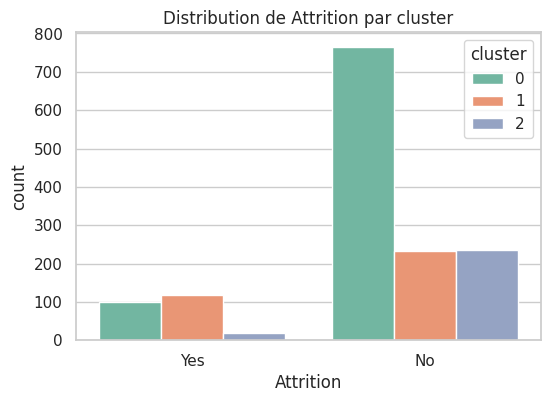

In [120]:
categorical_cols_plot = ['Gender', 'OverTime', 'Attrition']

for col in categorical_cols_plot:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='cluster', data=df, palette='Set2')
    plt.title(f'Distribution de {col} par cluster')
    plt.show()


cluster 1 : OverTime l'un de facteur princilape pour le départ

**Moyenne numérique par Cluster**

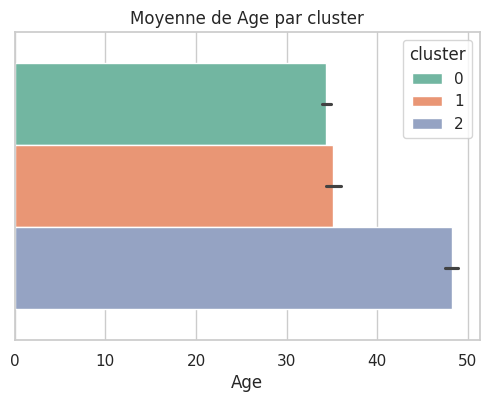

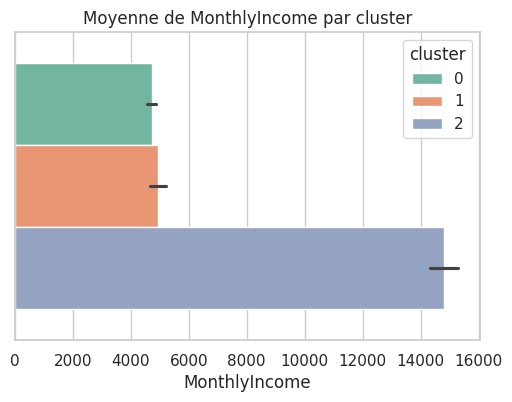

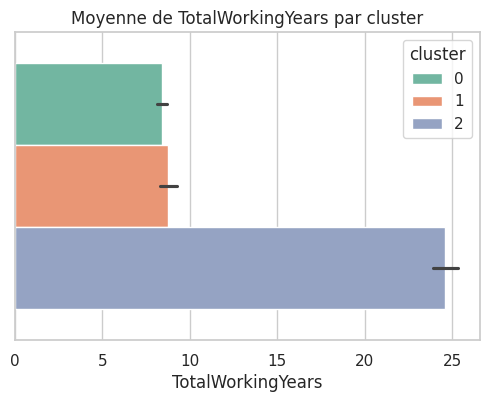

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exemple pour Age, MonthlyIncome et TotalWorkingYears
numerical_cols_plot = ['Age', 'MonthlyIncome', 'TotalWorkingYears']

for col in numerical_cols_plot:
    plt.figure(figsize=(6,4))
    sns.barplot(x= col, hue='cluster' , data=df, palette='Set2')
    plt.title(f'Moyenne de {col} par cluster')
    plt.show()


Cluster 2 : l'age et ancienntée se sont deux facteurs principeaux ansi que la salaire mensuelle